# Visualizations

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import time as t

# sparse matrix
from scipy.sparse import csc_array, csr_array

# this will handle the supported file formats
from imzy import get_reader

In [3]:
# File paths to .d folder
two_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\2week_3.9_neg\2week_3.9_neg.d"
four_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\4week_3.9_neg\4week_3.9_neg.d"

# Give path to reader
path = Path(four_week_path)
reader = get_reader(path)
print(reader)

### Spinal Cord TIC Image

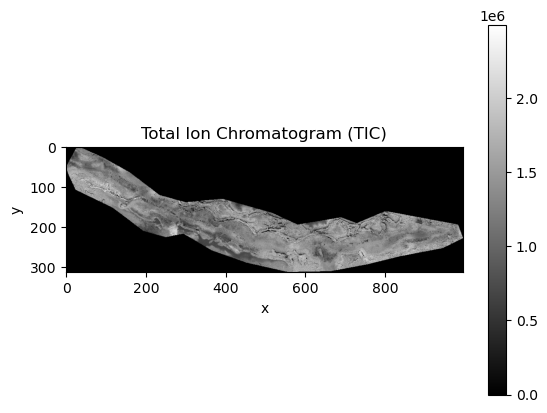

In [4]:
# get TIC array - TIC is returned as a 1D array
tic = reader.get_tic()
# convert the 1d array to 2d for visualization
tic2d = reader.reshape(tic)

# This is what our zebrafish spinal cord looks like
fig, ax = plt.subplots()
im = ax.imshow(tic2d, cmap="gray")
ax.set(title="Total Ion Chromatogram (TIC)", xlabel="x", ylabel="y")
plt.colorbar(im)
#plt.savefig('spinal_cord_tic.png', dpi=300, bbox_inches='tight')

In [25]:
# Good candidate for a pixel to align to
x_cond = reader.x_coordinates == 0
y_cond = reader.y_coordinates == 300

base_pixel_idx = np.where(x_cond & y_cond)[0]

In [26]:
print(base_pixel_idx)

[]


### Five Spectra Across the Spinal Cord

In [5]:
n_pixels = len(tic)
n_mz = len(reader[1][0])

#Print the shape of our data
print("We have " + str(n_pixels) + " pixels.")
print("We have " + str(n_mz) + " m/z values (columns).")

We have 109663 pixels.
We have 255681 m/z values (columns).


In [6]:
import random 

# random_pixels = []
# for i in range(5):
#     random_pixels.append(random.randrange(0, n_pixels), random_state=42)
random_pixels = [49760, 65024, 109629, 36486, 60089]

coords = []
for pix in random_pixels:
    coord = []
    coord.append(reader.x_coordinates[pix])
    coord.append(reader.y_coordinates[pix])
    coords.append(coord)

In [19]:
for i in range(5):
    print(f"Pixel {random_pixels[i]} at: " + str(coords[i]))

Pixel 49760 at: [714, 199]
Pixel 65024 at: [913, 218]
Pixel 109629 at: [632, 312]
Pixel 36486 at: [341, 181]
Pixel 60089 at: [657, 212]


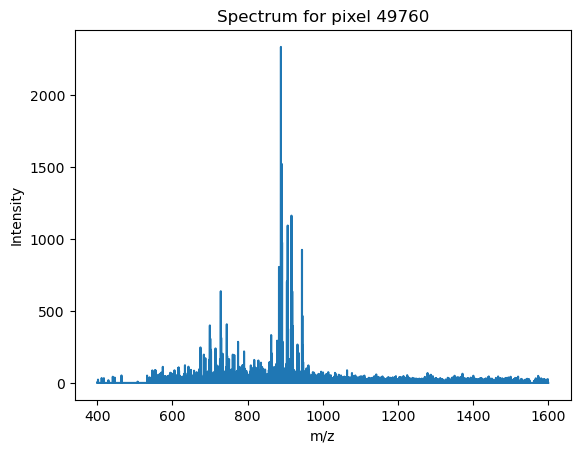

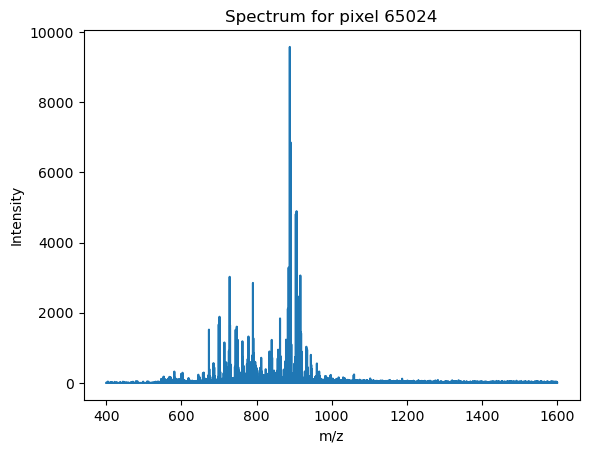

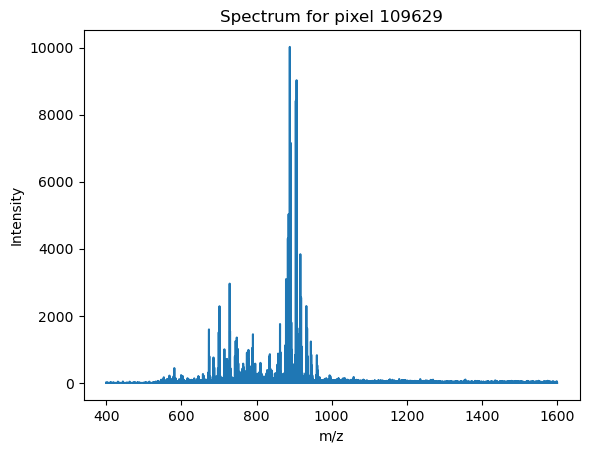

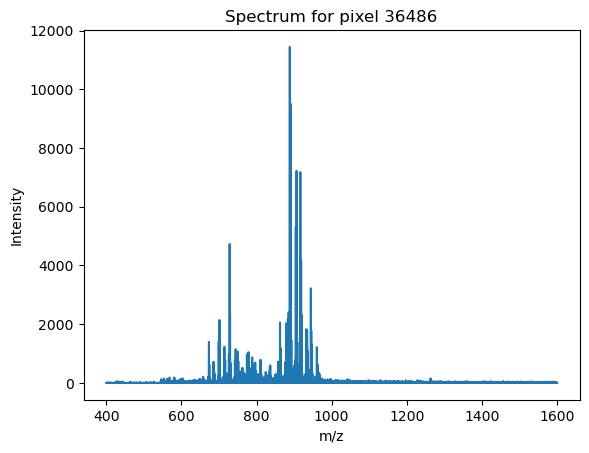

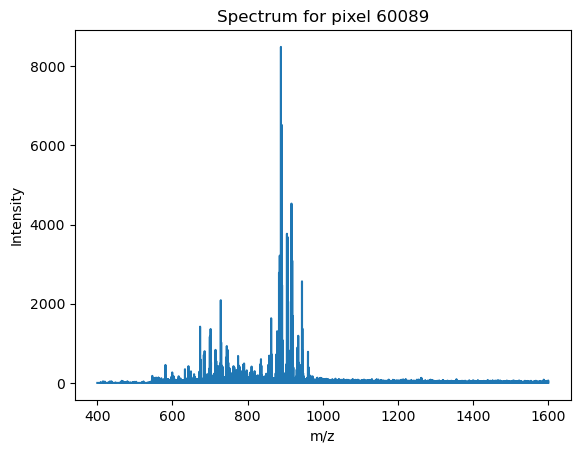

In [18]:
# Applying TIC Normalization to spectrum at pixel 0
for pix in random_pixels:
    x, y = reader.get_spectrum(pix)
    fig, ax = plt.subplots()
    ax.plot(x, y)
    _ = ax.set(xlabel="m/z", ylabel="Intensity", title=f"Spectrum for pixel {pix}")
    plt.savefig(f'pixel{pix}_spectrum.png', dpi=300, bbox_inches='tight')

### Ion Images

Iterating spectra...: 100%|███████████████████████████████████████████████████| 109663/109663 [02:29<00:00, 732.09it/s]


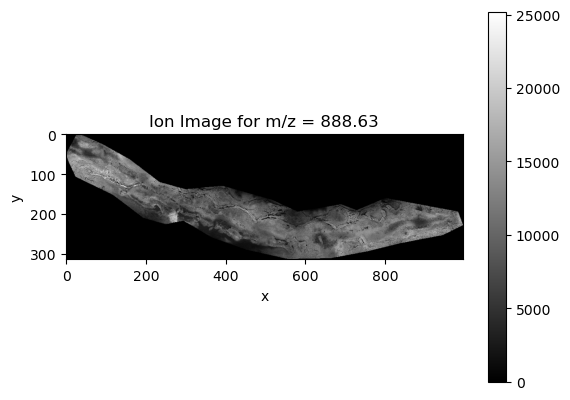

In [8]:
from scipy.signal import find_peaks

# get random spectrum from the dataset
x, y = reader.get_spectrum(0)

# find peaks in the spectrum
indices, _ = find_peaks(y, height=np.mean(y) + 3 * np.std(y), distance=5)
px = x[indices]
py = y[indices]

# extract ion image for a given m/z value with a tolerance
# let's get the highest peak in the spectrum
mz = px[np.argmax(py)]

# you can extract images one-by-one which can be fairly slow, or in batches
# here, we just get a single image with integration window of 5ppm but you could also specify in Da
image_for_mz = reader.get_ion_image(mz, ppm=5)

fig, ax = plt.subplots()
im = ax.imshow(image_for_mz, cmap="gray")
ax.set(title=f"Ion Image for m/z = {mz:.2f}", xlabel="x", ylabel="y")
plt.colorbar(im)

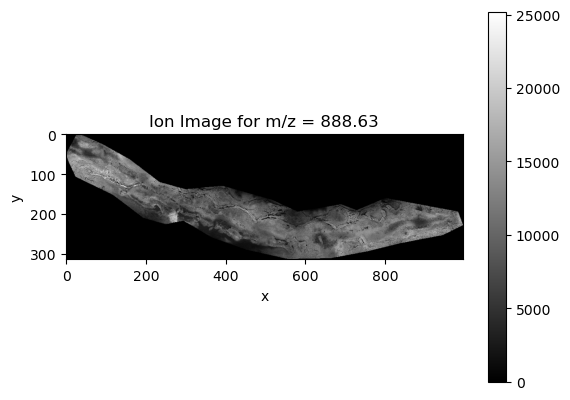

In [11]:
fig, ax = plt.subplots()
im = ax.imshow(image_for_mz, cmap="gray")
ax.set(title=f"Ion Image for m/z = {mz:.2f}", xlabel="x", ylabel="y")
plt.colorbar(im)
plt.savefig(f"Ion Image.png", dpi=300, bbox_inches='tight')

### Spectral Binning

In [26]:
def spectrum_to_binned_vector(pix):
    mzs, intensities = reader.get_spectrum(pix)
    bins = np.arange(400, 1600.1, .1)
    vec = np.zeros(len(bins) - 1)
    inds = np.digitize(mzs, bins) - 1
    for i, inten in zip(inds, intensities):
        if 0 <= i < len(vec):
            vec[i] += inten
    return bins[:-1], vec

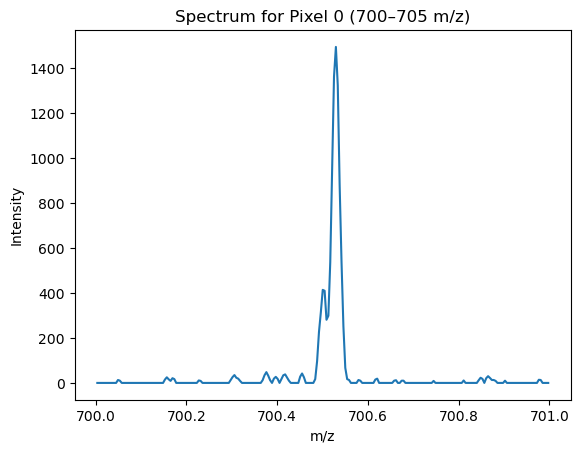

In [33]:
x, y = reader.get_spectrum(0)
mask = (x >= 700) & (x <= 701)
fig, ax = plt.subplots()
ax.plot(x[mask], y[mask])
ax.set(
    xlabel="m/z",
    ylabel="Intensity",
    title="Spectrum for Pixel 0 (700–705 m/z)"
)
plt.savefig(f'pixel0_spectrum.png', dpi=300, bbox_inches='tight')

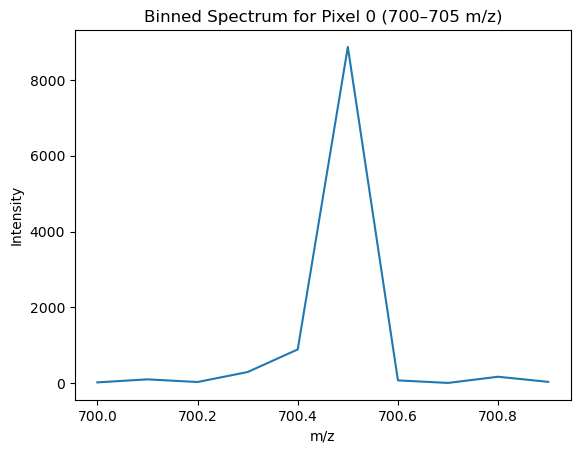

In [34]:
x, y = spectrum_to_binned_vector(0)
mask = (x >= 700) & (x <= 701)
fig, ax = plt.subplots()
ax.plot(x[mask], y[mask])
ax.set(
    xlabel="m/z",
    ylabel="Intensity",
    title="Binned Spectrum for Pixel 0 (700–705 m/z)"
)
plt.savefig(f'pixel0_binnedspectrum.png', dpi=300, bbox_inches='tight')

### Normalization

In [7]:
pixels = [49760, 65024]

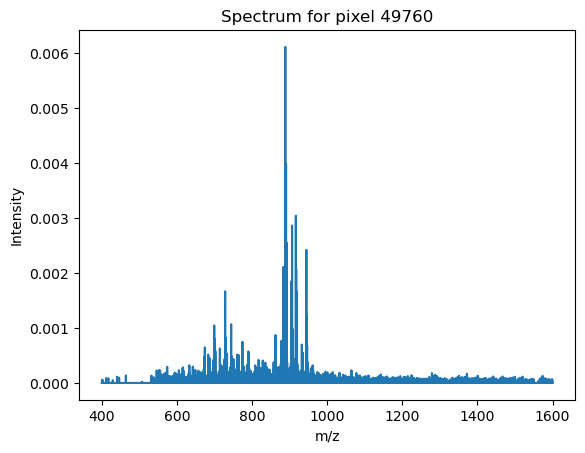

In [9]:
x, y = reader.get_spectrum(pixels[0])
y = y/tic[pixels[0]]
fig, ax = plt.subplots()
ax.plot(x, y)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title=f"Spectrum for pixel {pixels[0]}")
plt.savefig(f'pixel{pixels[0]}_normalizedspectrum.png', dpi=300, bbox_inches='tight')

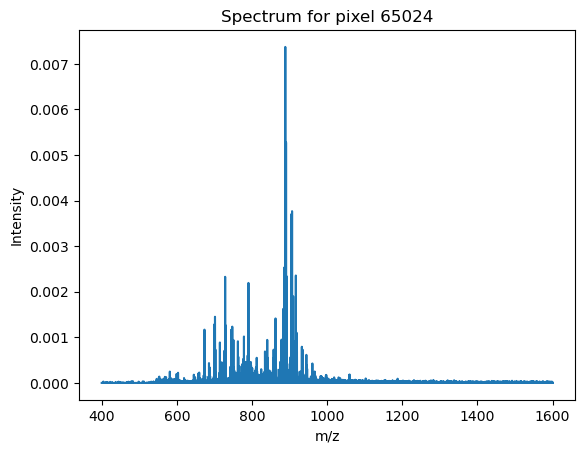

In [10]:
x, y = reader.get_spectrum(pixels[1])
y = y/tic[pixels[1]]
fig, ax = plt.subplots()
ax.plot(x, y)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title=f"Spectrum for pixel {pixels[1]}")
plt.savefig(f'pixel{pixels[1]}_normalizedspectrum.png', dpi=300, bbox_inches='tight')

### Verification of SVD

In [44]:
S = np.load(r"data/SVD/S.npy")  # (n_pixels, 100)
U = np.load(r"data/SVD/U.npy")
Vt = np.load(r"data/SVD/Vt.npy")
X_reduced = np.load(r"data/SVD/X_reduced.npy")

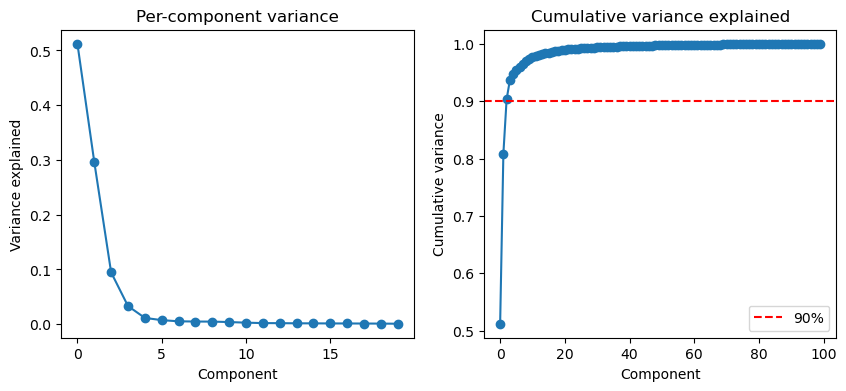

In [14]:
explained = (S**2) / (S**2).sum()
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(explained[:20], 'o-')
plt.xlabel("Component")
plt.ylabel("Variance explained")
plt.title("Per-component variance")


plt.subplot(1, 2, 2)
plt.plot(cumulative, 'o-')
plt.axhline(0.9, color='r', linestyle='--', label='90%')
plt.xlabel("Component")
plt.ylabel("Cumulative variance")
plt.title("Cumulative variance explained")
plt.legend()
plt.savefig(f'VarianceExplained.png', dpi=300, bbox_inches='tight')
plt.show()

# If the first component explains >50%, your data is dominated by one axis
# print(f"Component 0 explains: {explained[0]:.1%}")
# print(f"Components 0-4 explain: {cumulative[4]:.1%}")

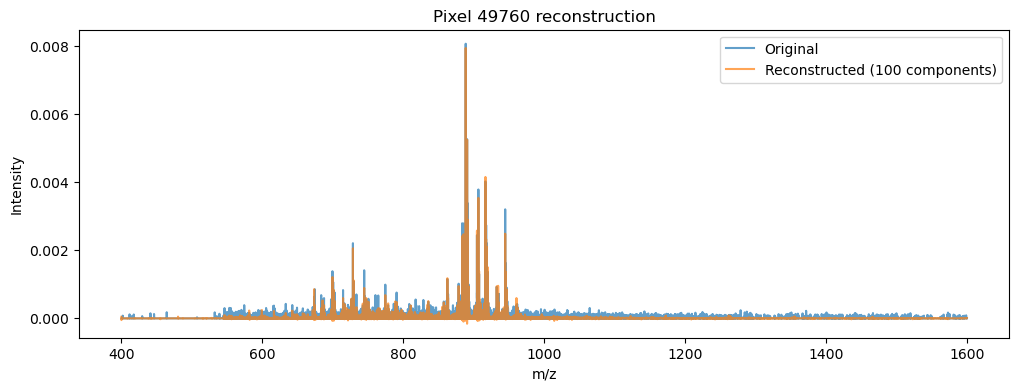

In [20]:
import zarr
import scipy.sparse as sp

# 4. Reconstruct a single pixel and compare to original
def load_batch(start, end):
    """Load a slice of rows from Zarr as a sparse matrix."""
    ptr_start = store["indptr"][start]
    ptr_end   = store["indptr"][end]
    data = np.nan_to_num(store["data"][ptr_start:ptr_end].astype('float32'), nan=0.0, posinf=0.0, neginf=0.0)
    return sp.csr_matrix(
        (data,
        store["indices"][ptr_start:ptr_end],
        store["indptr"][start:end+1] - store["indptr"][start]),
        shape = (end - start, n_mz_bins))

store = zarr.open("spectra_sparse.zarr", mode="r") 
n_pixels  = len(store["indptr"]) - 1
n_mz_bins = len(store["mz_axis"])

base_pixel_idx = pixels[0]
reconstructed = (U[base_pixel_idx, :] * S) @ Vt  # shape (n_mz_bins,)
batch = load_batch(base_pixel_idx, base_pixel_idx + 1).toarray().ravel() # Load the original

import matplotlib.pyplot as plt
mz_axis = store["mz_axis"][:]
plt.figure(figsize=(12, 4))
plt.plot(mz_axis, batch, label='Original', alpha=0.7)
plt.plot(mz_axis, reconstructed, label='Reconstructed (100 components)', alpha=0.7)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.legend()
plt.title(f"Pixel {base_pixel_idx} reconstruction")
plt.savefig(f'Pixel {base_pixel_idx} reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()

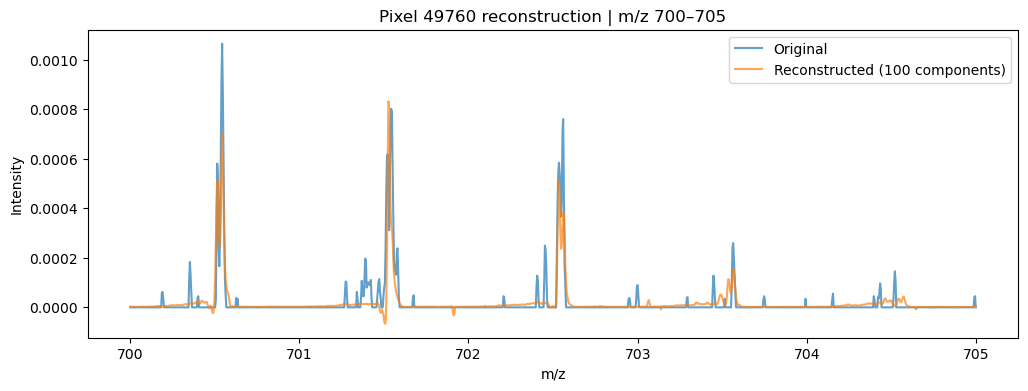

In [21]:
mz_min, mz_max = 700, 705
zoom_mask = (mz_axis >= mz_min) & (mz_axis <= mz_max)

plt.figure(figsize=(12, 4))
plt.plot(mz_axis[zoom_mask], batch[zoom_mask], label='Original', alpha=0.7)
plt.plot(mz_axis[zoom_mask], reconstructed[zoom_mask], label='Reconstructed (100 components)', alpha=0.7)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.legend()
plt.title(f"Pixel {base_pixel_idx} reconstruction | m/z {mz_min}–{mz_max}")
plt.savefig(f'Pixel {base_pixel_idx} reconstruction {mz_min}-{mz_max}.png', dpi=300, bbox_inches='tight')
plt.show()

### Bad K-means clustering

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.5, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr 21 21:14:52 2026 Construct fuzzy simplicial set
Tue Apr 21 21:14:52 2026 Finding Nearest Neighbors
Tue Apr 21 21:14:52 2026 Building RP forest with 22 trees
Tue Apr 21 21:14:54 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	Stopping threshold met -- exiting after 4 iterations
Tue Apr 21 21:15:04 2026 Finished Nearest Neighbor Search
Tue Apr 21 21:15:05 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Apr 21 21:16:23 2026 Finished embedding
k=2 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

...

k=21 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=23 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=24 done

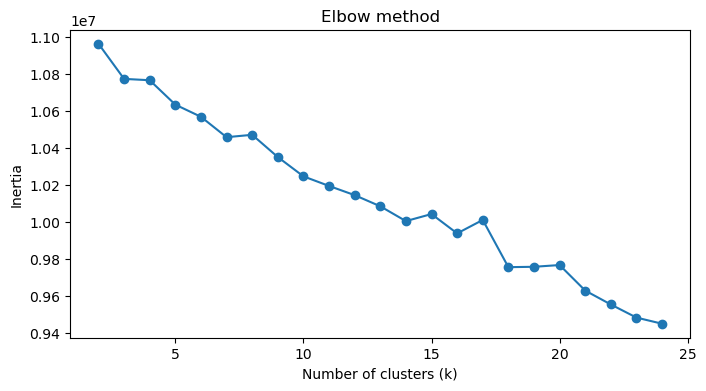

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


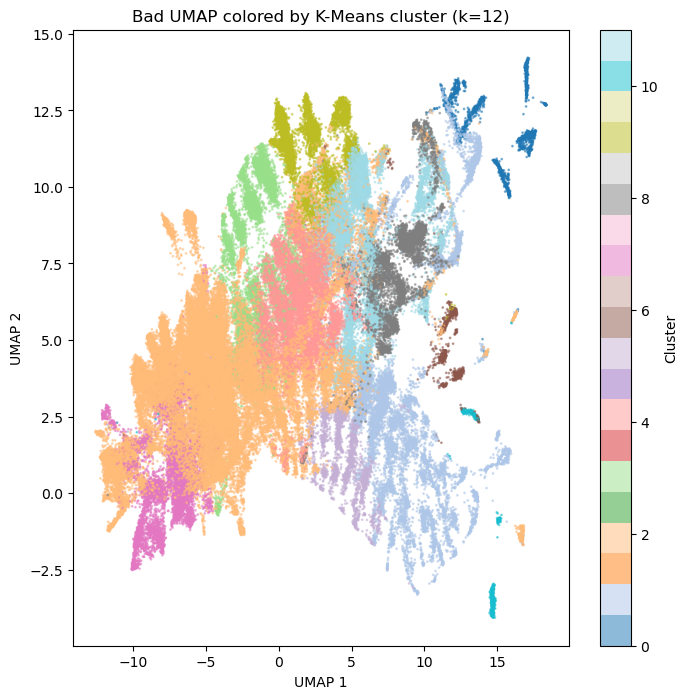

In [46]:
# ── 1. Scale ──────────────────────────────────────────────────────────────────
# SVD components have different variances — scaling puts them on equal footing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

# ── 2. UMAP ───────────────────────────────────────────────────────────────────
import umap
reducer = umap.UMAP(
    n_components=2,       # 2D embedding for visualization
    n_neighbors=30,       # Higher = more global structure preserved
    min_dist=0.5,         # Higher = more spread out clusters
    metric='euclidean',
    n_jobs=-1,
    random_state=42,
    verbose=True
)
embedding = reducer.fit_transform(X_scaled)  # (n_pixels, 2)

# ── 3. K-Means ────────────────────────────────────────────────────────────────
# Run on SVD-reduced data, not UMAP — UMAP distorts distances
# Use elbow method to pick k first

inertias = []
k_range = range(2, 25)
for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, init= 'k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k} done", end='\r')

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'o-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
#plt.savefig('BadElbowPlot.png', dpi=300, bbox_inches='tight')
plt.show()

k = 12  # replace with your chosen k
km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)  # (n_pixels,) cluster label per pixel

# ── 4. Visualize clusters on UMAP embedding ───────────────────────────────────
plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=labels, cmap='tab20',
    s=1, alpha=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.title(f"Bad UMAP colored by K-Means cluster (k={k})")
plt.savefig('BadUMAP.png', dpi=300, bbox_inches='tight')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

### ARI Plots

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

n_components= 20 | ARI: 0.505

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

n_components= 50 | ARI: 0.331

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

n_components= 75 | ARI: 0.231

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components=100 | ARI: 0.177

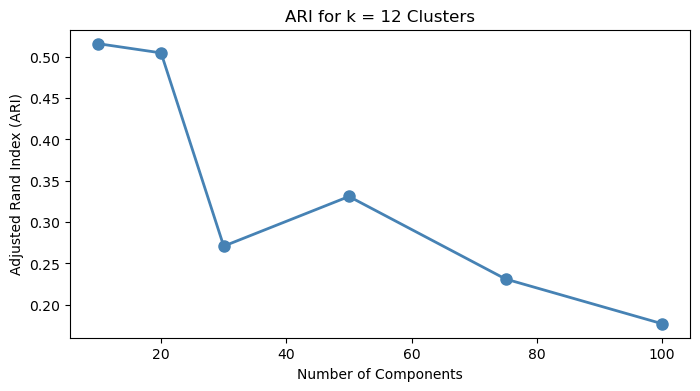

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score

n_comp_range = [10, 20, 30, 50, 75, 100]
ari_scores   = []
k=12 # agnostic choice

for n_comp in n_comp_range:
    X_test = StandardScaler().fit_transform(X_reduced[:, :n_comp])
    l1 = MiniBatchKMeans(n_clusters=k, random_state=42).fit_predict(X_test)
    l2 = MiniBatchKMeans(n_clusters=k, random_state=99).fit_predict(X_test)
    ari = adjusted_rand_score(l1, l2)
    ari_scores.append(ari)
    print(f"n_components={n_comp:3d} | ARI: {ari:.3f}", end='\r')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_comp_range, ari_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
_ = ax.set(ylabel="Adjusted Rand Index (ARI)", xlabel="Number of Components", title=f"ARI for k = {k} Clusters")
plt.savefig(f'NComponentsvsARI.png', dpi=300, bbox_inches='tight')

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components=  1 | ARI: 0.666

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

n_components=  2 | ARI: 0.742

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


...

n_components=  8 | ARI: 0.491

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components=  9 | ARI: 0.541

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components= 10 | ARI: 0.516

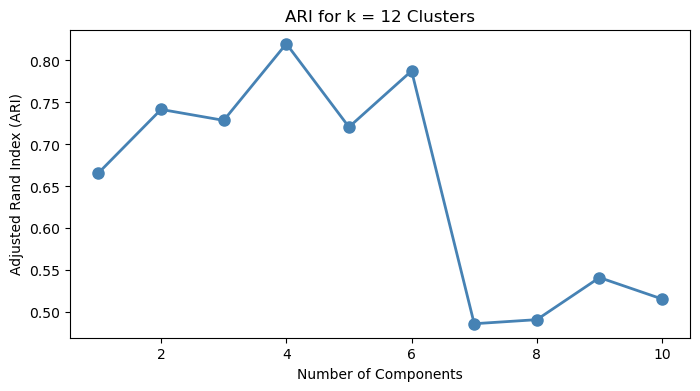

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score

n_comp_range = range(1, 11)
ari_scores   = []
k=12 # agnostic choice

for n_comp in n_comp_range:
    X_test = StandardScaler().fit_transform(X_reduced[:, :n_comp])
    l1 = MiniBatchKMeans(n_clusters=k, random_state=42).fit_predict(X_test)
    l2 = MiniBatchKMeans(n_clusters=k, random_state=99).fit_predict(X_test)
    ari = adjusted_rand_score(l1, l2)
    ari_scores.append(ari)
    print(f"n_components={n_comp:3d} | ARI: {ari:.3f}", end='\r')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_comp_range, ari_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
_ = ax.set(ylabel="Adjusted Rand Index (ARI)", xlabel="Number of Components", title=f"ARI for k = {k} Clusters")
plt.savefig(f'NComponentsvsARI2.png', dpi=300, bbox_inches='tight')

### Good K means

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.5, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr 21 21:16:30 2026 Construct fuzzy simplicial set
Tue Apr 21 21:16:30 2026 Finding Nearest Neighbors
Tue Apr 21 21:16:30 2026 Building RP forest with 22 trees
Tue Apr 21 21:16:30 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Tue Apr 21 21:16:37 2026 Finished Nearest Neighbor Search
Tue Apr 21 21:16:37 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Apr 21 21:18:53 2026 Finished embedding


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


...

k=21 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=23 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=24 done

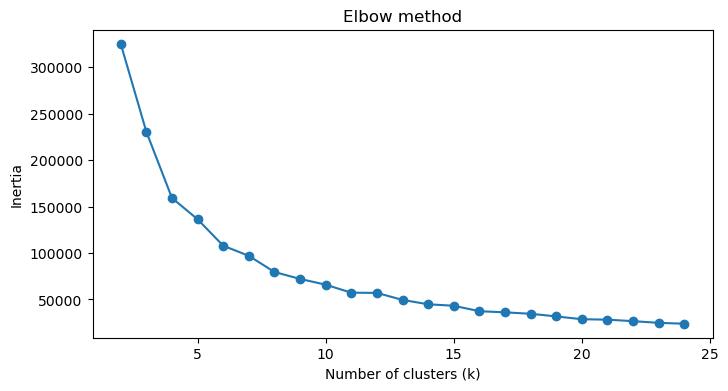

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


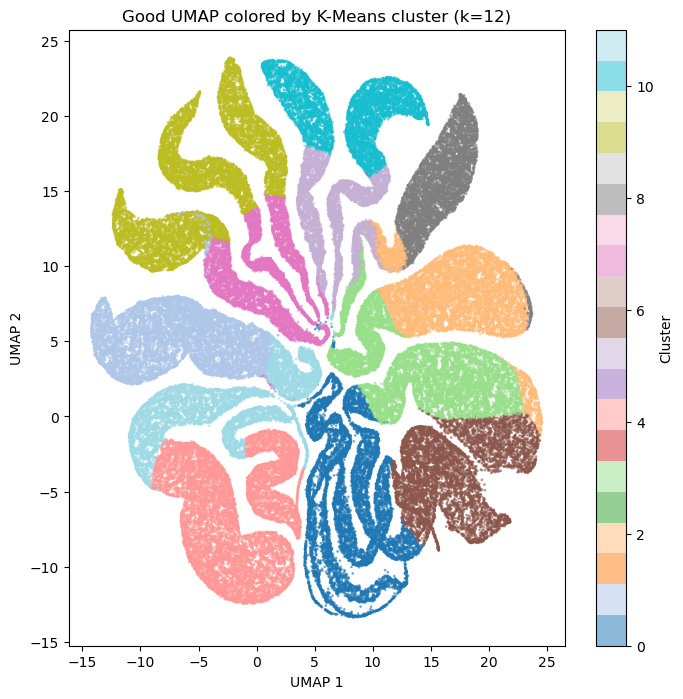

In [47]:
# ── 1. Scale ──────────────────────────────────────────────────────────────────
# SVD components have different variances — scaling puts them on equal footing
scaler = StandardScaler()
n_components = 4
X_scaled = scaler.fit_transform(X_reduced[:, :n_components])

# ── 2. UMAP ───────────────────────────────────────────────────────────────────
import umap
reducer = umap.UMAP(
    n_components=2,       # 2D embedding for visualization
    n_neighbors=30,       # Higher = more global structure preserved
    min_dist=0.5,         # Higher = more spread out clusters
    metric='euclidean',
    n_jobs=-1,
    random_state=42,
    verbose=True
)
embedding = reducer.fit_transform(X_scaled)  # (n_pixels, 2)

# ── 3. K-Means ────────────────────────────────────────────────────────────────
# Run on SVD-reduced data, not UMAP — UMAP distorts distances
# Use elbow method to pick k first

inertias = []
k_range = range(2, 25)
for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, init= 'k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k} done", end='\r')

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'o-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
#plt.savefig('GoodElbowPlot.png', dpi=300, bbox_inches='tight')
plt.show()

k = 12  # replace with your chosen k
km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)  # (n_pixels,) cluster label per pixel

# ── 4. Visualize clusters on UMAP embedding ───────────────────────────────────
plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=labels, cmap='tab20',
    s=1, alpha=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.title(f"Good UMAP colored by K-Means cluster (k={k})")
plt.savefig('GoodUMAP.png', dpi=300, bbox_inches='tight')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()